In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["WANDB_DISABLED"] = "true"

import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import json

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [2]:

print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

CUDA available: True


In [3]:
# -------------------------
# 1) Load CSVs (Kaggle paths)
# -------------------------
train_df = pd.read_csv("/kaggle/input/nlp-dataset/train.csv")
val_df   = pd.read_csv("/kaggle/input/nlp-dataset/validation.csv")
test_df  = pd.read_csv("/kaggle/input/nlp-dataset/test.csv")

# Auto-detect text and label columns from train
text_col = [c for c in train_df.columns if "tweet" in c.lower() or "text" in c.lower()][0]
label_col = [c for c in train_df.columns if "label" in c.lower()][0]

# Prepare dataframes
train_df = train_df[[text_col, label_col]].copy()
val_df   = val_df[[text_col, label_col]].copy()

train_df.columns = ["text", "label"]
val_df.columns = ["text", "label"]

# Some test files include labels, some not — detect
test_has_label = any("label" in c.lower() for c in test_df.columns)
if test_has_label:
    test_text_col = [c for c in test_df.columns if "tweet" in c.lower() or "text" in c.lower()][0]
    test_label_col = [c for c in test_df.columns if "label" in c.lower()][0]
    test_df = test_df[[test_text_col, test_label_col]].copy()
    test_df.columns = ["text", "label"]
else:
    test_text_col = [c for c in test_df.columns if "tweet" in c.lower() or "text" in c.lower()][0]
    test_df = test_df[[test_text_col]].copy()
    test_df.columns = ["text"]

# Map labels YES/NO to 1/0 if needed (only if labels are strings)
def map_labels_column(df):
    if "label" in df.columns:
        # if labels are strings YES/NO
        if df["label"].dtype == object:
            df["label"] = df["label"].map({"YES": 1, "NO": 0}).fillna(df["label"])
        # convert numeric-like strings
        df["label"] = pd.to_numeric(df["label"], errors="ignore")
    return df

train_df = map_labels_column(train_df)
val_df = map_labels_column(val_df)
if test_has_label:
    test_df = map_labels_column(test_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape, "| has_label:", test_has_label)
print("Sample train row:\n", train_df.iloc[0])


Train shape: (8456, 2)
Val shape: (2114, 2)
Test shape: (2109, 2) | has_label: True
Sample train row:
 text     camel cash gaining strength against the dollar
label                                                 1
Name: 0, dtype: object


/tmp/ipykernel_47/1100664796.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df["label"] = pd.to_numeric(df["label"], errors="ignore")
/tmp/ipykernel_47/1100664796.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df["label"] = pd.to_numeric(df["label"], errors="ignore")
/tmp/ipykernel_47/1100664796.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df["label"] = pd.to_numeric(df["label"], errors="ignore")


In [4]:
# -------------------------
# 2) Convert to HuggingFace Datasets
# -------------------------
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

# -------------------------
# 3) Load tokenizer & model
# -------------------------
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

# -------------------------
# 4) Tokenize (batched)
# -------------------------
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# remove only columns that exist (be robust)
def safe_remove_columns(dset, cols):
    cols_to_remove = [c for c in cols if c in dset.column_names]
    if cols_to_remove:
        return dset.remove_columns(cols_to_remove)
    return dset

train_ds = safe_remove_columns(train_ds, ["text", "__index_level_0__"])
val_ds = safe_remove_columns(val_ds, ["text", "__index_level_0__"])
test_ds = safe_remove_columns(test_ds, ["text", "__index_level_0__"])

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/8456 [00:00<?, ? examples/s]

Map:   0%|          | 0/2114 [00:00<?, ? examples/s]

Map:   0%|          | 0/2109 [00:00<?, ? examples/s]

In [5]:
# -------------------------
# 5) Training arguments (compatible)
# -------------------------
training_args = TrainingArguments(
    output_dir="/kaggle/working/simple_bert_output",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    num_train_epochs=3,
    logging_dir="/kaggle/working/logs",
    fp16=torch.cuda.is_available(),
    report_to="none",
)

# -------------------------
# 6) Trainer
# -------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

# -------------------------
# 7) Train
# -------------------------
trainer.train()



/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
500,0.119000


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=795, training_loss=0.1266252097843578, metrics={'train_runtime': 433.243, 'train_samples_per_second': 58.554, 'train_steps_per_second': 1.835, 'total_flos': 1668650313093120.0, 'train_loss': 0.1266252097843578, 'epoch': 3.0})

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



===== VALIDATION RESULTS =====
Accuracy: 0.9806054872280038
Weighted F1: 0.9805413351369183

Classification Report:
               precision    recall  f1-score   support

           0     0.9911    0.9582    0.9744       813
           1     0.9744    0.9946    0.9844      1301

    accuracy                         0.9806      2114
   macro avg     0.9827    0.9764    0.9794      2114
weighted avg     0.9808    0.9806    0.9805      2114



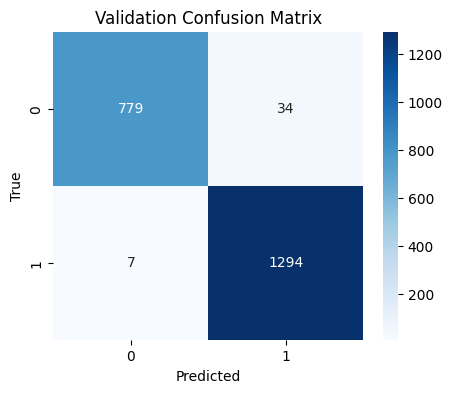

In [6]:
# -------------------------
# 8) Evaluate on Validation
# -------------------------
val_out = trainer.predict(val_ds)
val_logits = val_out.predictions
val_pred = np.argmax(val_logits, axis=1)
val_true = val_df["label"].values.astype(int)

val_acc = accuracy_score(val_true, val_pred)
val_f1  = f1_score(val_true, val_pred, average="weighted")

print("\n===== VALIDATION RESULTS =====")
print("Accuracy:", val_acc)
print("Weighted F1:", val_f1)
print("\nClassification Report:\n", classification_report(val_true, val_pred, digits=4))

cm_val = confusion_matrix(val_true, val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



===== TRAINING SET RESULTS =====
Accuracy: 0.9879375591296121
Weighted F1: 0.9879145072026175

Classification Report:
               precision    recall  f1-score   support

           0     0.9940    0.9745    0.9842      3253
           1     0.9842    0.9963    0.9903      5203

    accuracy                         0.9879      8456
   macro avg     0.9891    0.9854    0.9872      8456
weighted avg     0.9880    0.9879    0.9879      8456



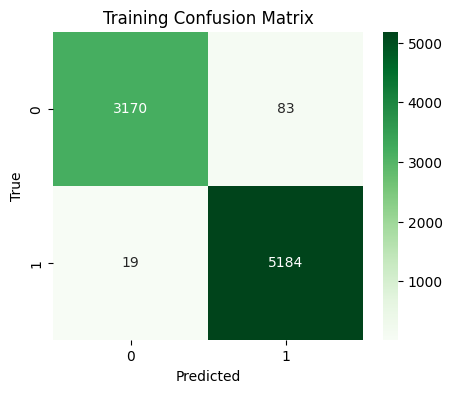

In [7]:
# -------------------------
# 9) Evaluate on Training set (optional, for overfit check)
# -------------------------
train_out = trainer.predict(train_ds)
train_logits = train_out.predictions
train_pred = np.argmax(train_logits, axis=1)
train_true = train_df["label"].values.astype(int)

train_acc = accuracy_score(train_true, train_pred)
train_f1  = f1_score(train_true, train_pred, average="weighted")

print("\n===== TRAINING SET RESULTS =====")
print("Accuracy:", train_acc)
print("Weighted F1:", train_f1)
print("\nClassification Report:\n", classification_report(train_true, train_pred, digits=4))

cm_train = confusion_matrix(train_true, train_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Greens")
plt.title("Training Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



===== EXTERNAL TEST SET (HAS LABELS) =====
Accuracy: 0.9829302987197724
Weighted F1: 0.9828808684471383

Classification Report:
               precision    recall  f1-score   support

           0     0.9855    0.9632    0.9742       706
           1     0.9817    0.9929    0.9872      1403

    accuracy                         0.9829      2109
   macro avg     0.9836    0.9780    0.9807      2109
weighted avg     0.9830    0.9829    0.9829      2109



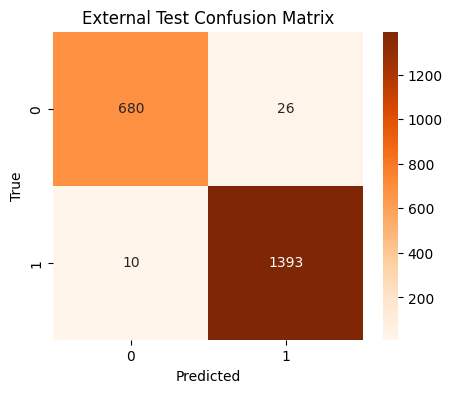

Saved test predictions to: /kaggle/working/test_predictions.csv


In [8]:
# -------------------------
# 10) Predict on external Test set
# -------------------------
test_out = trainer.predict(test_ds)
test_logits = test_out.predictions
test_pred = np.argmax(test_logits, axis=1)

# attach predictions to test_df
test_save_df = test_df.copy()
test_save_df["predicted_label"] = test_pred
if test_has_label:
    test_true = test_save_df["label"].astype(int).values
    test_acc = accuracy_score(test_true, test_pred)
    test_f1  = f1_score(test_true, test_pred, average="weighted")
    print("\n===== EXTERNAL TEST SET (HAS LABELS) =====")
    print("Accuracy:", test_acc)
    print("Weighted F1:", test_f1)
    print("\nClassification Report:\n", classification_report(test_true, test_pred, digits=4))
    cm_test = confusion_matrix(test_true, test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Oranges")
    plt.title("External Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
else:
    print("\nExternal test had no labels. Predictions saved.")

# Save test predictions CSV
out_path = "/kaggle/working/test_predictions.csv"
test_save_df.to_csv(out_path, index=False)
print("Saved test predictions to:", out_path)

In [9]:
# -------------------------
# 11) Save metrics summary
# -------------------------
metrics = {
    "train": {"accuracy": float(train_acc), "weighted_f1": float(train_f1)},
    "validation": {"accuracy": float(val_acc), "weighted_f1": float(val_f1)},
}
if test_has_label:
    metrics["test"] = {"accuracy": float(test_acc), "weighted_f1": float(test_f1)}

with open("/kaggle/working/metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics to /kaggle/working/metrics_summary.json")




Saved metrics to /kaggle/working/metrics_summary.json


In [10]:
# -------------------------
# 12) Extract & display CLS embeddings for a few examples (test set)
# -------------------------
print("\nExtracting CLS embeddings (first 3 test samples)...")
model.eval()
cls_list = []
with torch.no_grad():
    # prepare batch of first 3 test samples
    for i in range(min(3, len(test_save_df))):
        enc = tokenizer(test_save_df["text"].iloc[i], return_tensors="pt", truncation=True, padding=True, max_length=128)
        enc = {k: v.to(device) for k, v in enc.items()}
        # use base model to get hidden states (works for BERT-like models)
        base = getattr(model, model.base_model_prefix)  # typically model.bert
        out = base(**enc)
        # last_hidden_state shape: (1, seq_len, hidden_dim)
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()  # CLS token embedding
        cls_list.append(cls_emb[0])

cls_array = np.vstack(cls_list) if cls_list else np.zeros((0, model.config.hidden_size))
print("CLS embeddings shape:", cls_array.shape)
print("First CLS embedding (first 10 dims):", cls_array[0][:10] if cls_array.shape[0] > 0 else "N/A")




Extracting CLS embeddings (first 3 test samples)...
CLS embeddings shape: (3, 768)
First CLS embedding (first 10 dims): [-0.25612012  0.18971643 -1.3472452  -0.38628438 -1.296281   -0.29786476
  0.6008329  -0.45513558 -0.30903956  0.03296208]


In [11]:
# -------------------------
# 13) Save model & tokenizer to /kaggle/working
# -------------------------
save_path = "/kaggle/working/simple_bert_finetuned"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print("Saved fine-tuned model to:", save_path)

Saved fine-tuned model to: /kaggle/working/simple_bert_finetuned


In [ ]:
!zip -r /kaggle/working/output.zip /kaggle/working/


  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/state.db

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 11%)
  adding: kaggle/working/logs/ (stored 0%)
  adding: kaggle/working/logs/events.out.tfevents.1763550525.83ad2c5fbc53.48.0 (deflated 62%)
  adding: kaggle/working/logs/events.out.tfevents.1763550839.83ad2c5fbc53.48.1 (deflated 60%)
  adding: kaggle/working/logs/events.out.tfevents.1764499209.d91a077d3678.47.0 (deflated 60%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/test_predictions.csv (deflated 54%)
  adding: kaggle/working/metrics_summary.json (deflated 50%)
  adding: kaggle/working/simple_bert_finetuned/ (stored 0%)
  adding: kaggle/working/simple_bert_finetuned/special_tokens_map.json (deflated 42%)
  adding: kaggle/working/simple_bert_finetuned/vocab.txt (deflated 45%)
  adding: kaggle/working/simple_bert_finetuned/training_args.bin (deflated 52%)
  adding: kaggle/working/simple_bert_finetuned/config.json (deflated 54%)
  adding: kaggle/working/simple_bert_finetuned/tokenizer_config.json (deflated 75%)
  adding: kaggle/working